### About Plotly
> Plotly is a Data Viz library by the company Plotly based out of Canada with support in languages such as Python, Js, Julia etc.
Advantages
* Multi language support
* Lot's of graphs
* Interactive plots
* Beautiful plots
> Does not work with live data streams. Dash can be explored for that.
### The Plotly Roadmap
* Plotly Go (like matplotlib)
* Plotly Express (like seaborn)
* Dash (like streamlit)

### Working With Plotly Go (graph object)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [17]:
patient = pd.read_csv('IndividualDetails.csv')
patient.head()

,id,government_id,diagnosed_date,age,gender,detected_city,detected_district,detected_state,nationality,current_status,status_change_date,notes
0,0,KL-TS-P1,30/01/2020,20,F,Thrissur,Thrissur,Kerala,India,Recovered,14/02/2020,Travelled from Wuhan
1,1,KL-AL-P1,02/02/2020,NaN,NaN,Alappuzha,Alappuzha,Kerala,India,Recovered,14/02/2020,Travelled from Wuhan
2,2,KL-KS-P1,03/02/2020,NaN,NaN,Kasaragod,Kasaragod,Kerala,India,Recovered,14/02/2020,Travelled from Wuhan
3,3,DL-P1,02/03/2020,45,M,East Delhi (Mayur Vihar),East Delhi,Delhi,India,Recovered,15/03/2020,"Travelled from Austria, Italy"
4,4,TS-P1,02/03/2020,24,M,Hyderabad,Hyderabad,Telangana,India,Recovered,02/03/2020,"Travelled from Dubai to Bangalore on 20th Feb,..."


In [21]:
total = patient.shape[0]
active = patient[patient['current_status']=='Hospitalized'].shape[0]
recovered = patient[patient['current_status']=='Recovered'].shape[0]
deaths = patient[patient['current_status']=='Deceased'].shape[0]
patient.columns

Index(['id', 'government_id', 'diagnosed_date', 'age', 'gender',
       'detected_city', 'detected_district', 'detected_state', 'nationality',
       'current_status', 'status_change_date', 'notes'],
      dtype='object')

In [23]:
patient['current_status'].unique()

array(['Recovered', 'Hospitalized', 'Deceased', 'Migrated', nan],
      dtype=object)

In [25]:
pbar = patient['detected_state'].value_counts().reset_index()
pbar

,detected_state,count
0,Maharashtra,1761
1,Delhi,1069
2,Tamil Nadu,969
3,Rajasthan,700
4,Madhya Pradesh,529
5,Telangana,503
6,Gujarat,468
7,Uttar Pradesh,452
8,Andhra Pradesh,405
9,Kerala,373


In [2]:
## import dataset 
tips = px.data.tips()
iris = px.data.iris()
gap = px.data.gapminder()

In [9]:
gap['pop']

0        8425333
1        9240934
2       10267083
3       11537966
4       13079460
          ...   
1699     9216418
1700    10704340
1701    11404948
1702    11926563
1703    12311143
Name: pop, Length: 1704, dtype: int64

In [7]:
gap.to_csv('gapminder.csv',index=False)

In [3]:
temp = gap[gap['year']==2007]
temp

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32
...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894


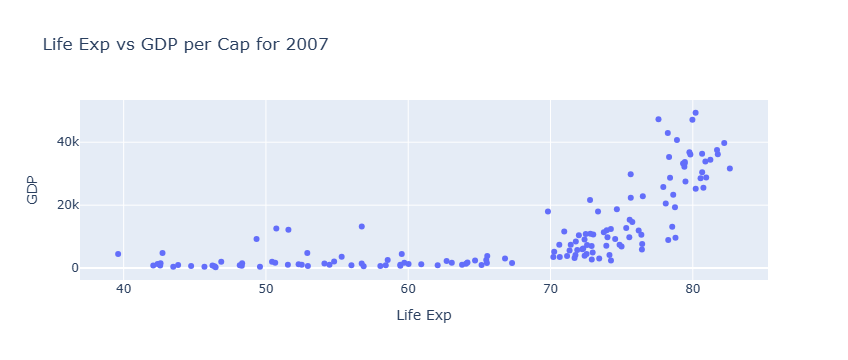

In [20]:
## scatter plot using plotly go
trace1 = go.Scatter(x=temp['lifeExp'],y=temp['gdpPercap'],mode='markers')

data = [trace1]
layout = go.Layout(title='Life Exp vs GDP per Cap for 2007',xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig = go.Figure(data,layout)

fig.show()

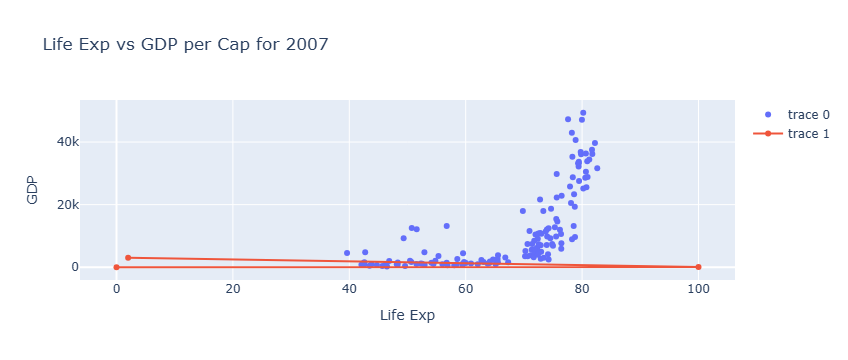

In [30]:
trace0 = go.Scatter(x=temp['lifeExp'],y=temp['gdpPercap'],mode='markers')
trace1 = go.Scatter(x=[0,100,2],y=[0,90,3000])

data = [trace0,trace1]
layout = go.Layout(title='Life Exp vs GDP per Cap for 2007',xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig = go.Figure(data,layout)

fig.show()

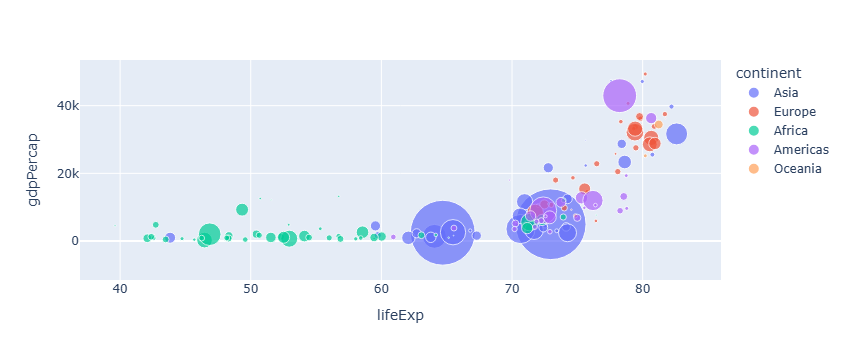

In [38]:
## plot life axp and gdp scatter plot -> continent as color -> pop as size -> hover_name->range_x/range_y -> log_x/ log_y
px.scatter(temp, x='lifeExp', y='gdpPercap',
           color='continent',size='pop',
           size_max=50,hover_name='country')

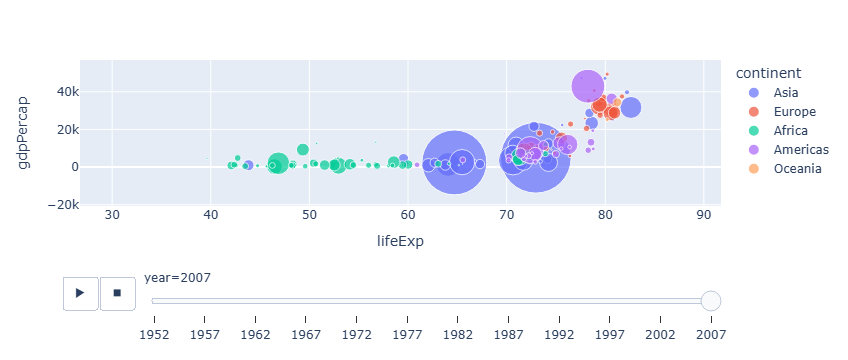

In [42]:
## plot animation of the above curve on the basis of year
px.scatter(gap, x='lifeExp', y='gdpPercap',
           color='continent',size='pop',
           range_x=[30,95],
           size_max=50,hover_name='country',
          animation_frame='year',animation_group='country')

In [48]:
## line plot 
## plot india pop line plot
temp_df = gap[gap['country']=='India']
temp_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356
701,India,Asia,1977,54.208,634000000,813.337323,IND,356
702,India,Asia,1982,56.596,708000000,855.723538,IND,356
703,India,Asia,1987,58.553,788000000,976.512676,IND,356
704,India,Asia,1992,60.223,872000000,1164.406809,IND,356
705,India,Asia,1997,61.765,959000000,1458.817442,IND,356


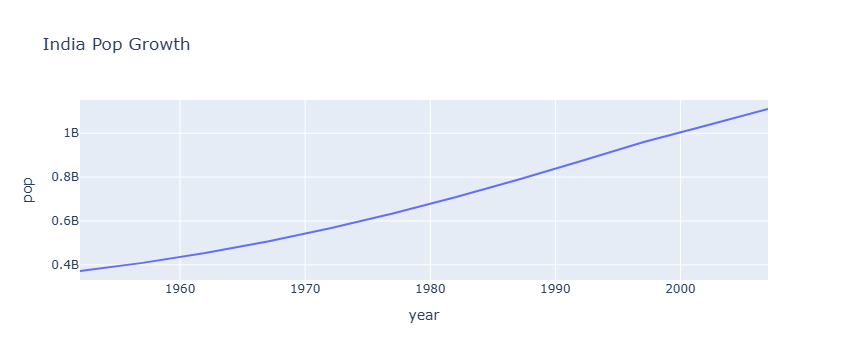

In [54]:
px.line(temp_df, x='year',y='pop',title='India Pop Growth')

In [62]:
## plot india , china and pak line plot
df = gap[gap['country'].isin(['India','China','Pakistan'])]
df.sample(5)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
701,India,Asia,1977,54.20800,634000000,813.337323,IND,356
291,China,Asia,1967,58.38112,754550000,612.705693,CHN,156
288,China,Asia,1952,44.00000,556263527,400.448611,CHN,156
707,India,Asia,2007,64.69800,1110396331,2452.210407,IND,356
1172,Pakistan,Asia,1992,60.83800,120065004,1971.829464,PAK,586


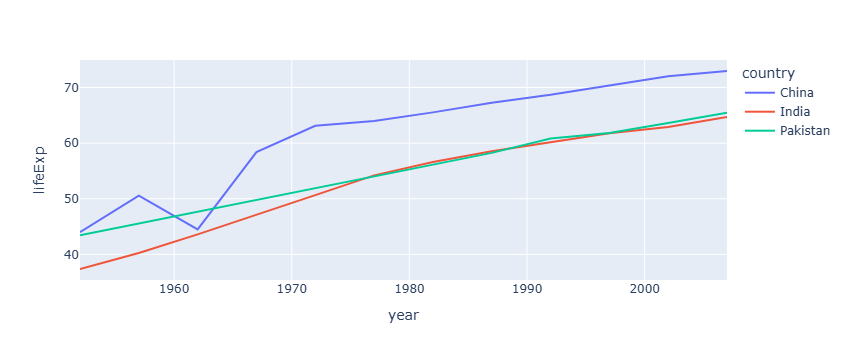

In [68]:
px.line(df,x='year',y='lifeExp',hover_name='country',color='country')

In [70]:
df = gap[gap['country'].isin(['India','China','Pakistan'])].pivot(index='year',
                            columns='country',values='lifeExp')
df.sample(5)

country,China,India,Pakistan
year,,,
1987,67.27400,58.553,58.245
1992,68.69000,60.223,60.838
2002,72.02800,62.879,63.610
1957,50.54896,40.249,45.557
1972,63.11888,50.651,51.929


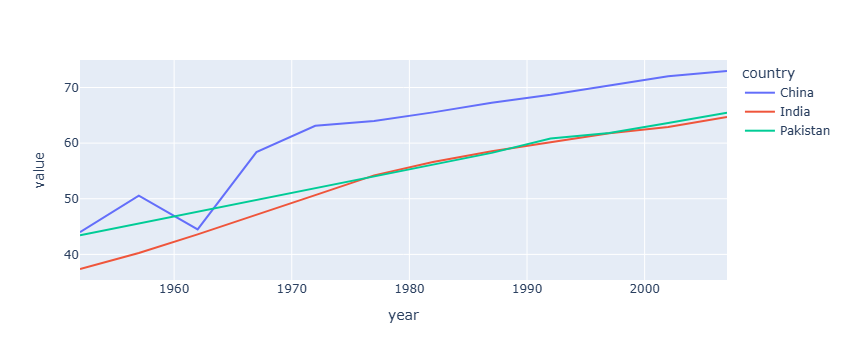

In [72]:
px.line(df,x=df.index,y=df.columns)

In [76]:
## bar chart
### india's pop over the year
temp = gap[gap['country']=='India']
temp

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356
701,India,Asia,1977,54.208,634000000,813.337323,IND,356
702,India,Asia,1982,56.596,708000000,855.723538,IND,356
703,India,Asia,1987,58.553,788000000,976.512676,IND,356
704,India,Asia,1992,60.223,872000000,1164.406809,IND,356
705,India,Asia,1997,61.765,959000000,1458.817442,IND,356


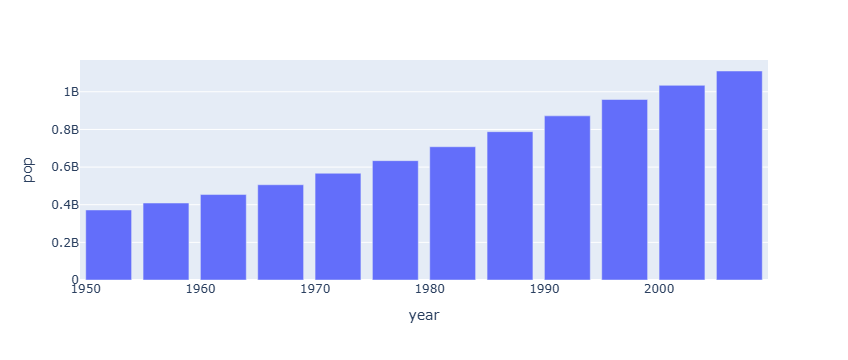

In [78]:
px.bar(temp,x='year',y='pop')

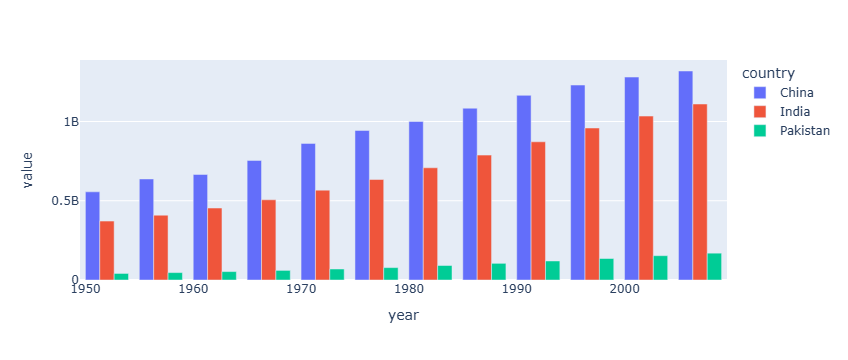

In [92]:
## pop comp of 3 countries
df = gap[gap['country'].isin(['India','China','Pakistan'])].pivot(index='year',
                                columns='country',values='pop')
px.bar(df,x=df.index,y=df.columns,barmode='group')

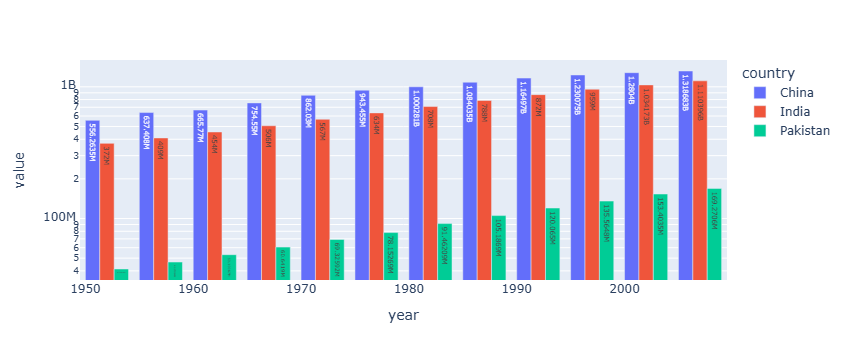

In [96]:
px.bar(df,x=df.index,y=df.columns,barmode='group',log_y=True,text_auto=True)

In [102]:
## stacked bar chart
## pop contribution per country to a continent pop stacked for a particular year(2007)
df = gap[gap['year']==2007]
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32
...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894


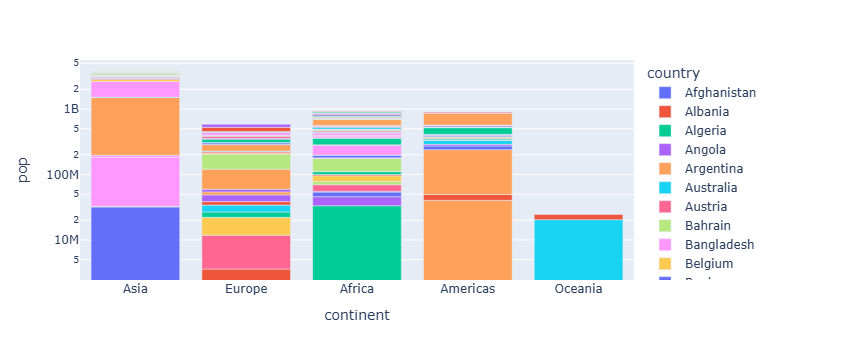

In [116]:
px.bar(df,x='continent',y='pop',color='country',log_y=True)

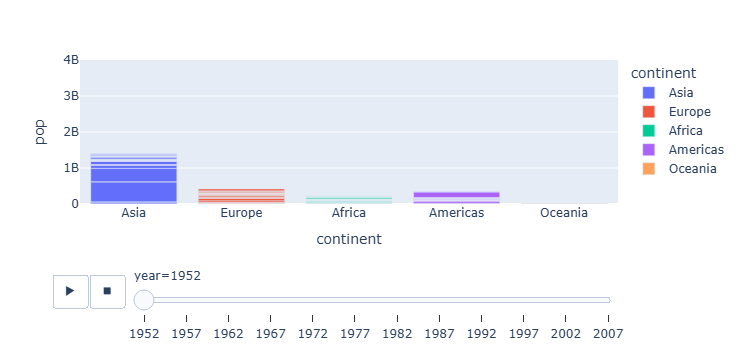

In [128]:
## bar chart animation
px.bar(gap,x='continent',y='pop',color='continent',animation_frame='year'
       ,range_y=[0,4000000000],animation_group='country')

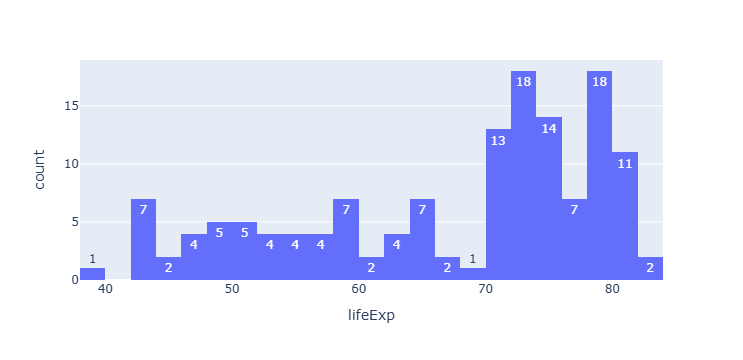

In [138]:
### histogram
## plot histogram of life expt of all countries in 2007 -> nbins -> text_auto
temp = gap[gap['year']==2007]
px.histogram(temp,x='lifeExp',text_auto=True,nbins=35)

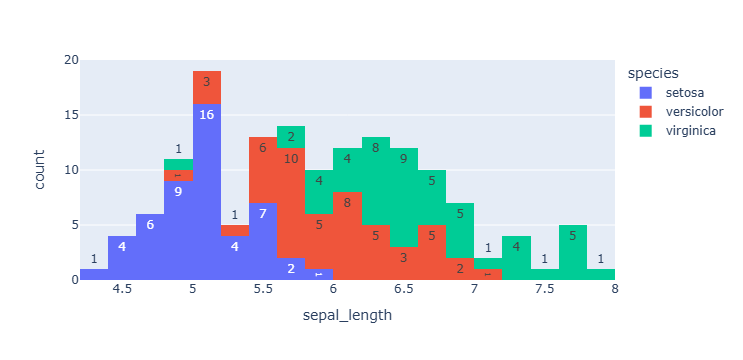

In [144]:
## plot histogram of sepal length of all iris species
px.histogram(iris,x='sepal_length',color='species',text_auto=True,nbins=30)

In [160]:
## pie chart ->values ->names
## find the pie chart of europian countries in 2007
df = gap[(gap['continent']=='Europe') & (gap['year']==2007)]
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
83,Austria,Europe,2007,79.829,8199783,36126.492700,AUT,40
119,Belgium,Europe,2007,79.441,10392226,33692.605080,BEL,56
155,Bosnia and Herzegovina,Europe,2007,74.852,4552198,7446.298803,BIH,70
191,Bulgaria,Europe,2007,73.005,7322858,10680.792820,BGR,100
383,Croatia,Europe,2007,75.748,4493312,14619.222720,HRV,191
407,Czech Republic,Europe,2007,76.486,10228744,22833.308510,CZE,203
419,Denmark,Europe,2007,78.332,5468120,35278.418740,DNK,208
527,Finland,Europe,2007,79.313,5238460,33207.084400,FIN,246
539,France,Europe,2007,80.657,61083916,30470.016700,FRA,250


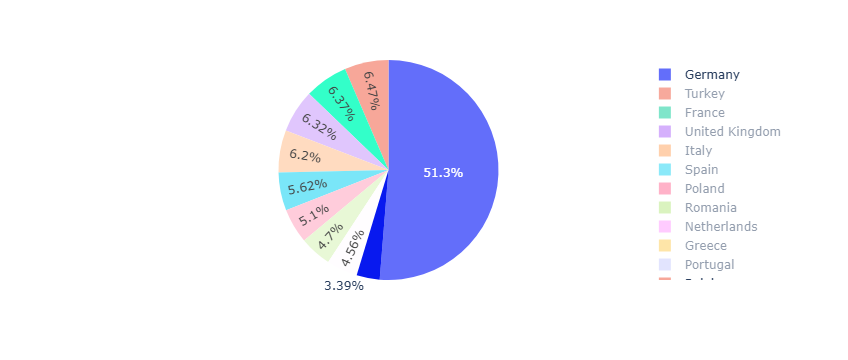

In [164]:
px.pie(df,values='pop',names='country')

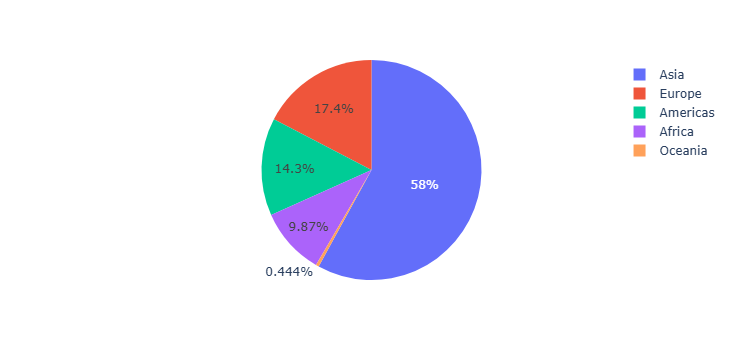

In [174]:
## plot pie chart of world pop in 1952 continent wise ---> explode(pull can not be used in px)
df = gap[gap['year']==1952].groupby('continent')['pop'].sum().reset_index()
px.pie(df,values='pop',names='continent')

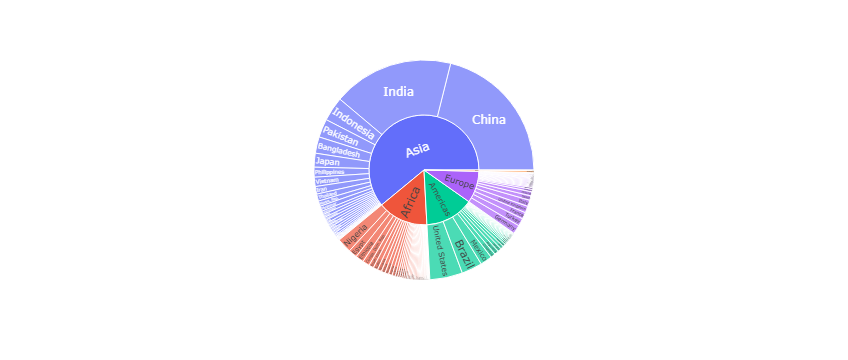

In [176]:
## sunburst plot -> sunburst plot visualize the hierarical data apannings outwards radially from root to leaves -> color
## path -> [] , values
temp = gap[gap['year']==2007]
px.sunburst(temp,path=['continent','country'],values='pop')

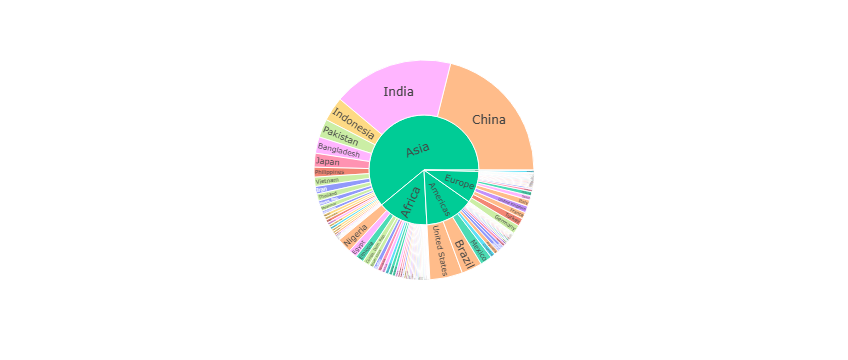

In [178]:
temp = gap[gap['year']==2007]
px.sunburst(temp,path=['continent','country'],values='pop',color='country')

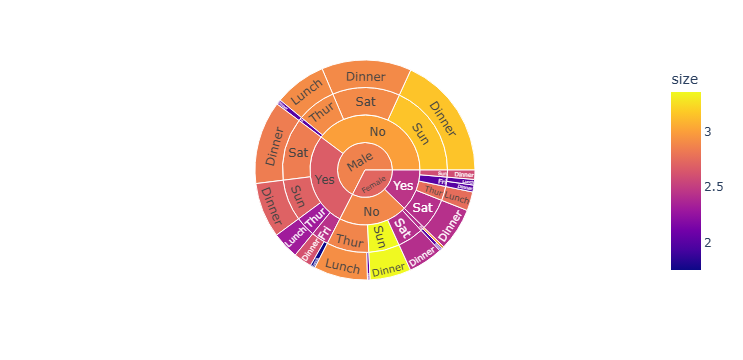

In [182]:
px.sunburst(tips,path=['sex','smoker','day','time'],values='total_bill',color='size')

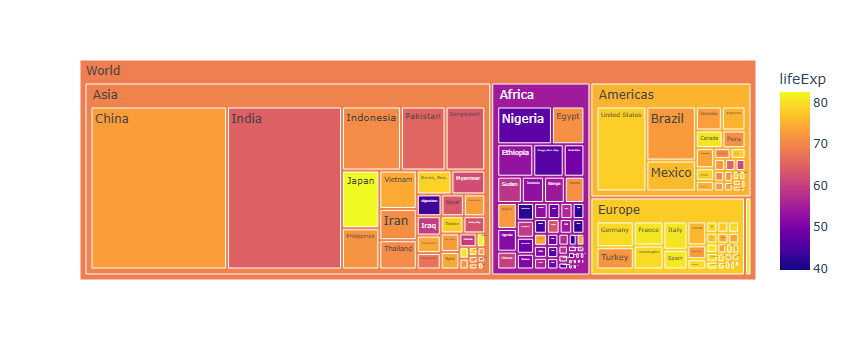

In [184]:
## treemap
temp = gap[gap['year']==2007]
px.treemap(temp,path=[px.Constant('World'),'continent','country'],values='pop',color='lifeExp')

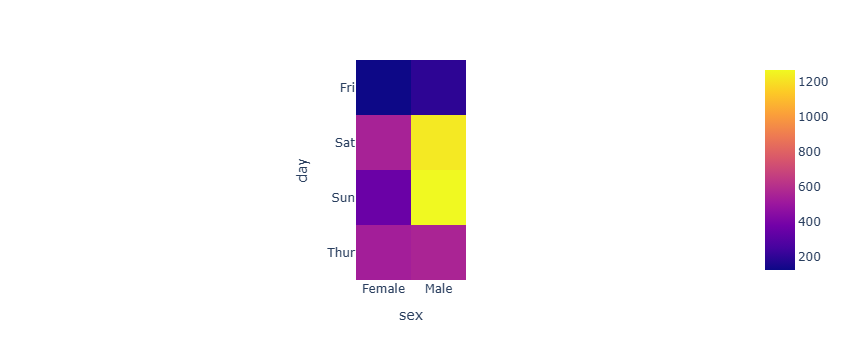

In [186]:
## heatmap -> find heatmap of all continents with year on avg life exp
temp = tips.pivot_table(index='day',columns='sex',values='total_bill',aggfunc='sum')

px.imshow(temp)

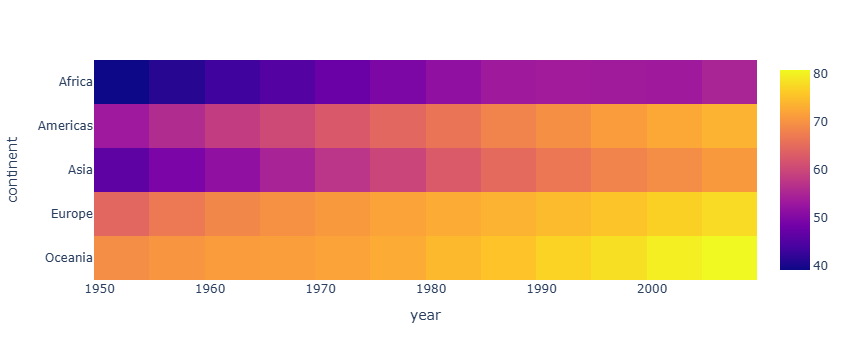

In [190]:
df = gap.pivot_table(index='continent',columns='year',values='lifeExp',aggfunc='mean')
px.imshow(df)

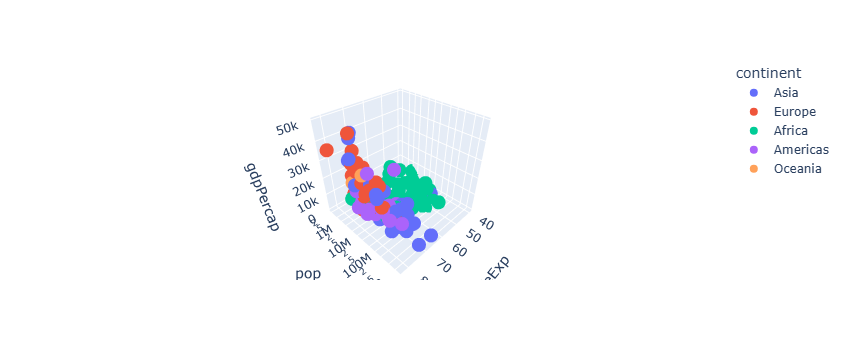

In [200]:
## 3D scatter plot
## plot a 3d scatter plot of all country date for 2007
df = gap[gap['year']==2007]
px.scatter_3d(df,x='lifeExp',y='pop',z='gdpPercap',log_y=True,color='continent',hover_name='country')

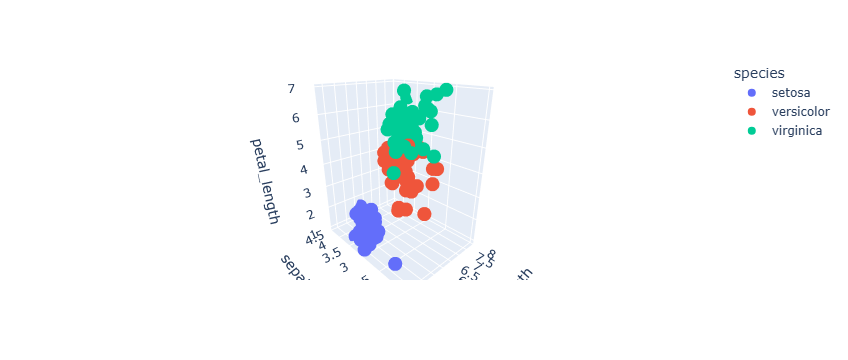

In [206]:
px.scatter_3d(iris,x='sepal_length',y='sepal_width',z='petal_length',color='species',log_y=True)

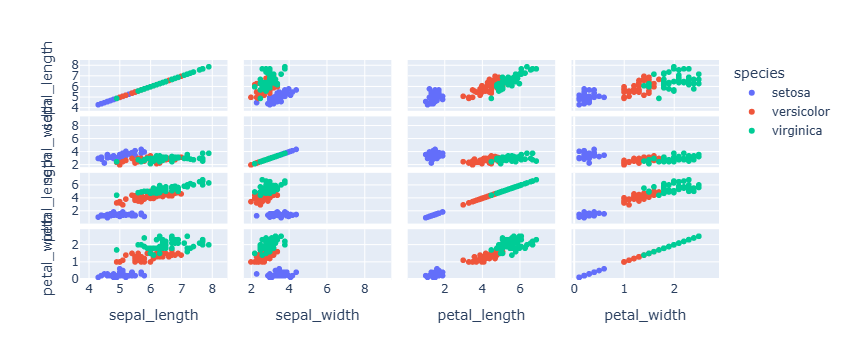

In [214]:
## scatter_matrix -> dimensions
px.scatter_matrix(iris,dimensions=['sepal_length','sepal_width','petal_length','petal_width'],color='species')